In [45]:
import numpy as np
from matplotlib import pyplot as plt

Define the problem parameters


In [46]:
A = np.array([[1, 3], [3, 1]]) # low dimensions to plot it, you can test larger sizes
b = np.array([-1, 2])

lmbda = 0.5


The function to be minimized is $\frac{1}{2}\|Ax-b\|_2^2 + \lambda \|x\|_1$

In [47]:
f = lambda x: 0.5 * np.sum((A @ x - b) ** 2)
F = lambda x: f(x) + lmbda * np.sum(np.abs(x))

# derivative of f from matrix calculus
df = lambda x: A.T @ (A @ x) - A.T @ b


Plot the function

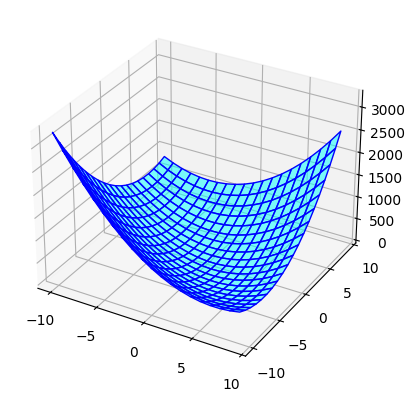

In [48]:
# this function has been prepared only for the visualization sake, no need to go through this but it renders some nice
# graphics :)
Fplot = lambda r1, r2: (r1 * A[0, 0] + r2 * A[0, 1] - b[0]) ** 2 + (r1 * A[1, 0] + r2 * A[1,1] - b[1]) ** 2 + lmbda * (np.abs(r1) + np.abs(r2))
xx, yy = np.meshgrid(np.arange(-10, 10, 1), np.arange(-10, 10, 1))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])

ISTA with backtracking
----------------------------
Parameters of ISTA

In [49]:
MAX_ITER = 1e3
TOL_DIST_X = 1e-6
# initial value for alpha
alpha = 1
# parameter for backtracking
eta = 0.99

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [50]:
x = np.array([-5, 10])

grad_norm = 1e10
distanceX = 1e10

# initialize the list with all the estimates
all_x = [x]
x_past = x

Main loop

In [51]:
def soft_thresholding(x):    
    # perform soft thresholding of x
    for i, component in enumerate(x):
    # Minimum at the right 
        if component > lmbda:
            x[i] += - lmbda
        # Minimum in the left
        elif component < -lmbda:
            x[i] += lmbda
        # 0
        else:
            x[i] =0
    return x


cnt = 0
alpha_current = alpha
while cnt < MAX_ITER and distanceX > TOL_DIST_X:
    print(f"{cnt +1} iteration: ")
    # compute the argument of the proximal operator
    x_current = x_past - alpha_current * df(x_past)

    # perform thresholding
    x_current = soft_thresholding(x_current)

    # iterate the backtracking procedure until the stopping criterion is met
    while f(x_current) > f(x_past) + (df(x_past) @ (x_current - x_past)) + (1/(2* alpha_current)) * np.linalg.norm(x_current-x_past)**2:
        #print(f"Computing the backtracking {alpha_current}... {f(x_current)} > {f(x_past) + df(x_past) @ (x_current - x_past) + (1/(2* alpha_current)) * np.linalg.norm(x_current-x_past)**2}")
        cnt = cnt + 1
      # update alpha
        alpha_current = eta * alpha_current

        # compute again x
        x_current = x_past - alpha_current * df(x_past)

        # perform soft thresholding
        x_current = soft_thresholding(x_current)

    # compute the stopping criteria
    distanceX = np.linalg.norm(x_past- x_current)
    print(f"{x_current}")
    # store the estimate
    x_past = x_current
    all_x.append(x_current)
    cnt +=1



1 iteration: 
[-4.99552408  2.4635581 ]
232 iteration: 
[-0.5140979   2.39343153]
233 iteration: 
[-0.43228159  0.        ]
234 iteration: 
[0. 0.]
235 iteration: 
[0. 0.]


Plot all the estimates

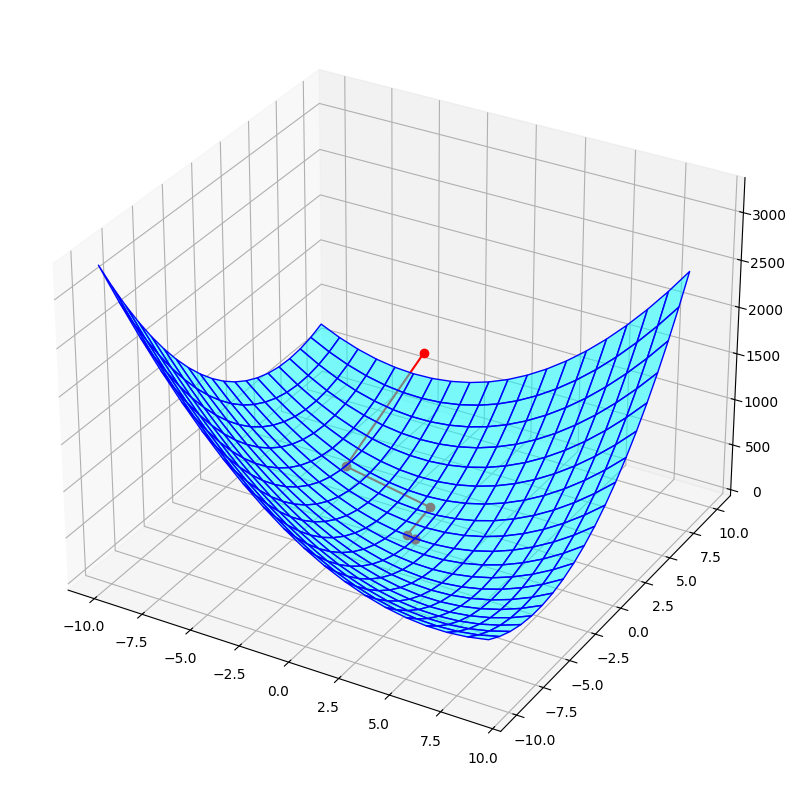

In [52]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = Fplot(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

Compare the number of iteration needed for convergence with backtracking with the number of iteration required using the optimal alpha

In [53]:
print(f'nr of iteration of ISTA with backtracking (before stopping criteria met): {cnt}\n')
print(f'Solution of ISTA: [{x_current[0]:.4f}, {x_current[1]:.4f}]\n')
print(f'Value of the functional: {F(x_current):.4f}\n')

nr of iteration of ISTA with backtracking (before stopping criteria met): 235

Solution of ISTA: [0.0000, 0.0000]

Value of the functional: 2.5000



FISTA
-----
Parameters of FISTA

In [54]:
MAX_ITER = 1e3
TOL_DIST_X = 1e-6
# set the optimal value for alpha
alpha = 1 / np.max(np.linalg.eigvals(A.T@A))

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [55]:
# initialize x
x = np.array([5, 10])

# initialize y
y = x

# initialize gamma
gamma = 1

grad_norm = 1e10
distanceX = 1e10

# initialize the list with all the estimates
all_x = [x]



Main loop

In [56]:
def soft_thresholding(x):    
    # perform soft thresholding of x
    for i, component in enumerate(x):
    # Minimum at the right 
        if component > lmbda:
            x[i] += - lmbda
        # Minimum in the left
        elif component < -lmbda:
            x[i] += lmbda
        # 0
        else:
            x[i] =0
    return x


cnt = 0
alpha_current = alpha
while cnt < MAX_ITER and distanceX > TOL_DIST_X:
    # compute the argument of the proximal operator
    x = y - alpha_current * df(y)
    # perform soft thresholding of x
    x = soft_thresholding(x)
    # update gamma
    gamma_past  = gamma
    gamma = (1+np.sqrt(1+4* gamma_past**2))/2
    # update y
    y = x + ((gamma - 1) /gamma_past) * (x- all_x[-1]) 
    # compute the stopping criteria
    distanceX = np.linalg.norm(all_x[-1] - x)   
    # store the estimate
    all_x.append(x)
    print(f"x : {x}, alpha: {alpha_current}")
    cnt +=1


x : [-1.0625  1.3125], alpha: 0.0625
x : [0. 0.], alpha: 0.0625
x : [ 0.4694609 -0.2194609], alpha: 0.0625
x : [ 0.27692976 -0.02692976], alpha: 0.0625
x : [0. 0.], alpha: 0.0625
x : [0. 0.], alpha: 0.0625


Plot all the estimates

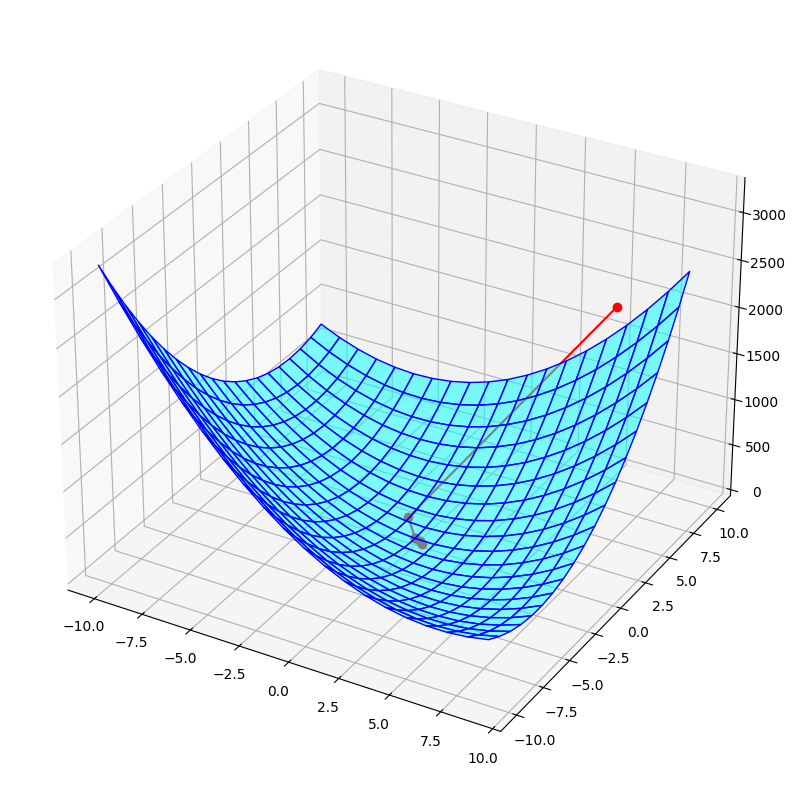

In [57]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = Fplot(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

In [58]:
print(f'nr of iteration of FISTA (before stopping criteria met): {cnt}\n')
print(f'Solution of FISTA: [{x[0]:.4f}, {x[1]:.4f}]\n')
print(f'Value of the functional: {F(x):.4f}\n')

nr of iteration of FISTA (before stopping criteria met): 6

Solution of FISTA: [0.0000, 0.0000]

Value of the functional: 2.5000

